Epoch 1: Loss = 0.0296
Epoch 2: Loss = 0.0208
Epoch 3: Loss = 0.0172
Epoch 4: Loss = 0.0153
Epoch 5: Loss = 0.0138
Epoch 6: Loss = 0.0127
Epoch 7: Loss = 0.0119
Epoch 8: Loss = 0.0111
Epoch 9: Loss = 0.0105
Epoch 10: Loss = 0.0100

Test Accuracy: 94.13%


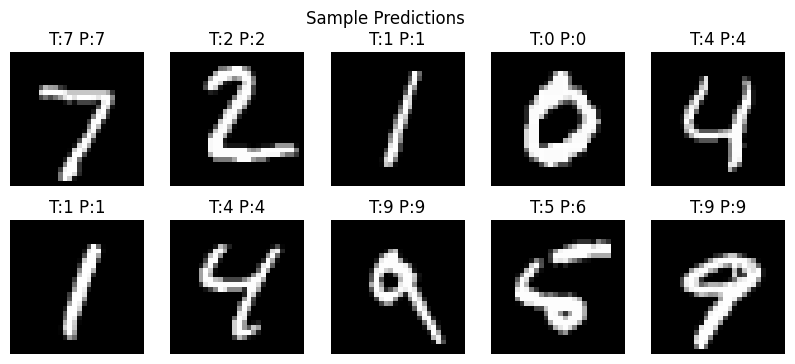

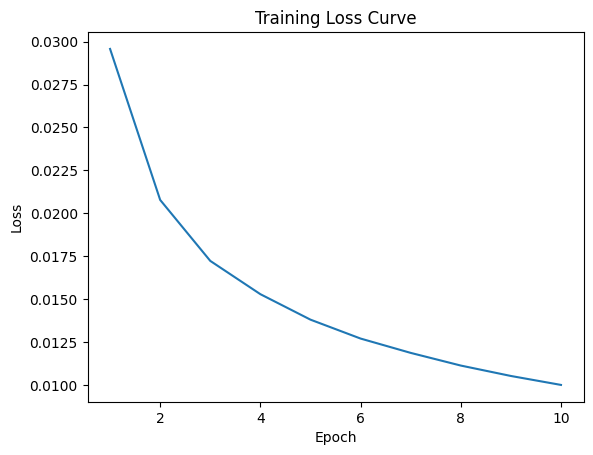

In [ ]:
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

# Load MNIST
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
urllib.request.urlretrieve(url, "mnist.npz")

data = np.load("mnist.npz")

X_train = data['x_train'].reshape(-1, 784) / 255.0
y_train = data['y_train']

X_test = data['x_test'].reshape(-1, 784) / 255.0
y_test = data['y_test']


# One-hot encoding
def one_hot(y):
    oh = np.zeros((y.size, 10))
    oh[np.arange(y.size), y] = 1
    return oh

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)


# STEP 1 — Sigmoid
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)


# STEP 2 — Forward Pass
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3


# STEP 3 — MSE Loss
def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)


# STEP 4 — Backpropagation
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):

    m = X.shape[0]
    
    # Output layer
    delta3 = -2*(Y_true - A3) * sigmoid_derivative(A3)
    
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    
    # Hidden layer 2
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    
    # Hidden layer 1
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    
    return dW1, db1, dW2, db2, dW3, db3


# STEP 5 — Weight Update
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    
    return W1, b1, W2, b2, W3, b3


# Initialization
np.random.seed(42)

W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))

W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))

W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))


# Training Loop
learning_rate = 0.1
epochs = 10
batch_size = 32

loss_history = []

for epoch in range(epochs):
    
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = y_train_oh[idx]
    
    for start in range(0, X_train.shape[0], batch_size):
        
        X_batch = X_shuf[start:start+batch_size]
        Y_batch = Y_shuf[start:start+batch_size]
        
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        
        dW1, db1, dW2, db2, dW3, db3 = backpropagation( X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)
        
        W1, b1, W2, b2, W3, b3 = update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3,learning_rate)
    
    _,_,_,_,_,A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(y_train_oh, A3_full)
    
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")


# Test Accuracy
_,_,_,_,_,A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)

preds = np.argmax(A3_test, axis=1)
accuracy = np.mean(preds == y_test) * 100

print(f"\nTest Accuracy: {accuracy:.2f}%")


# Sample Predictions (10 images)
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    img = X_test[i].reshape(28,28)
    pred = preds[i]
    true = y_test[i]
    
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{true} P:{pred}")
    plt.axis('off')

plt.suptitle("Sample Predictions")
plt.show()


# Loss Curve
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()